# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mubashirsidiki/student-academic-performance-500-students/student_performance.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mubashirsidiki/student-academic-performance-500-students/student_performance.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


## last Five row

In [4]:
df.tail()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
495,STU0496,Female,19,6,78.3,Master,No,No,51,27,No
496,STU0497,Female,16,27,61.1,PhD,No,No,47,74,Yes
497,STU0498,Female,18,16,72.3,Master,No,Yes,52,61,Yes
498,STU0499,Male,17,29,91.3,NaN,Yes,No,39,86,Yes
499,STU0500,Male,15,29,75.4,High School,No,Yes,34,74,Yes


## Shape of our dataset

In [5]:
df.shape

(500, 11)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'gender', 'age', 'study_hours_per_week',
       'attendance_rate', 'parent_education', 'internet_access',
       'extracurricular', 'previous_score', 'final_score', 'passed'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id               object
gender                   object
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education         object
internet_access          object
extracurricular          object
previous_score            int64
final_score               int64
passed                   object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


## Check Null Value

In [9]:
df.isnull().sum()

student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

## Drop Parent Education Feature

In [10]:
df.drop(columns=['parent_education'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

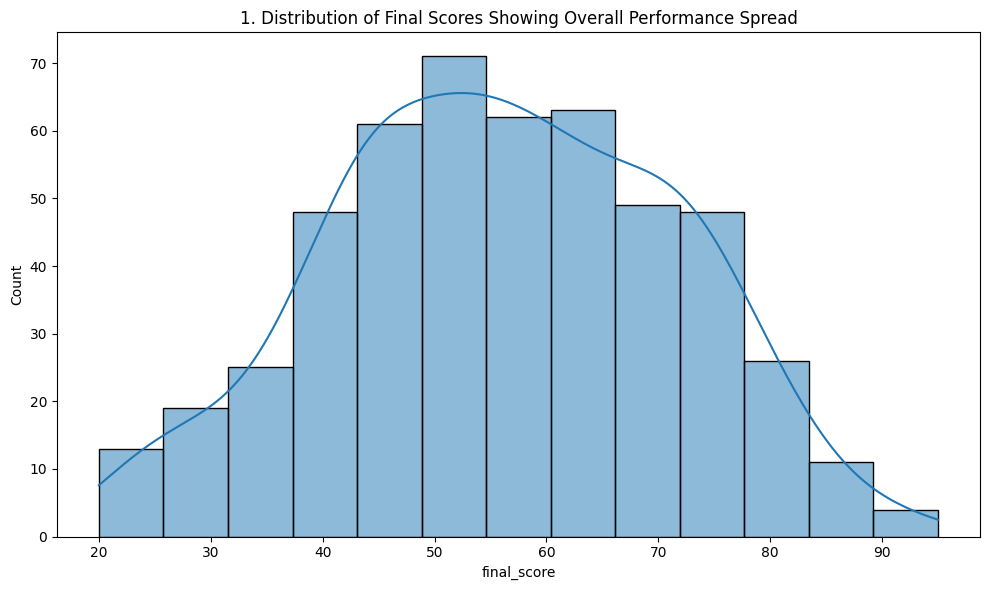

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['final_score'], kde=True)
plt.title(f'{plot_no}. Distribution of Final Scores Showing Overall Performance Spread')
show_fig()
plot_no += 1

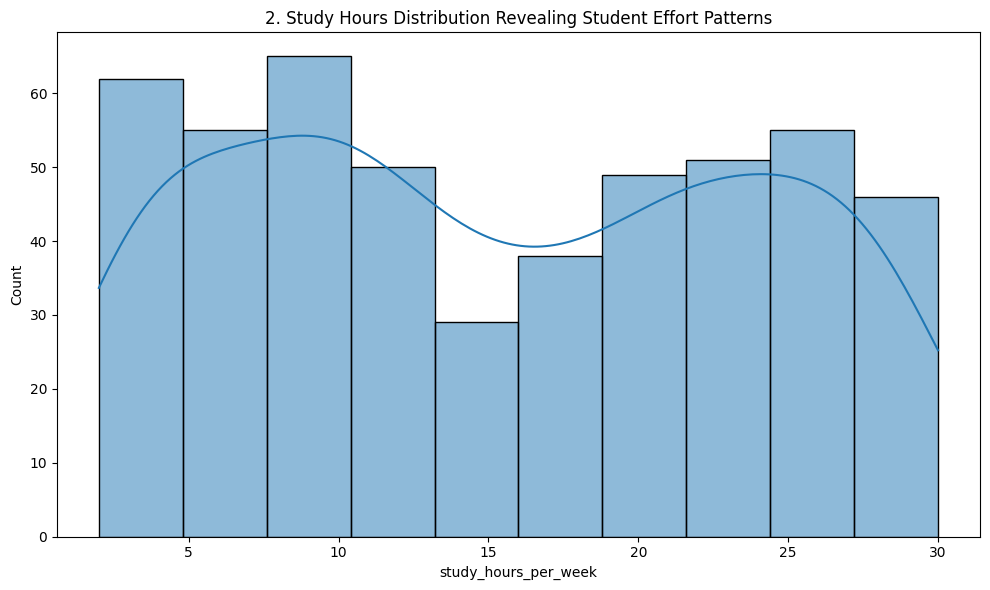

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['study_hours_per_week'], kde=True)
plt.title(f'{plot_no}. Study Hours Distribution Revealing Student Effort Patterns')
show_fig()
plot_no += 1

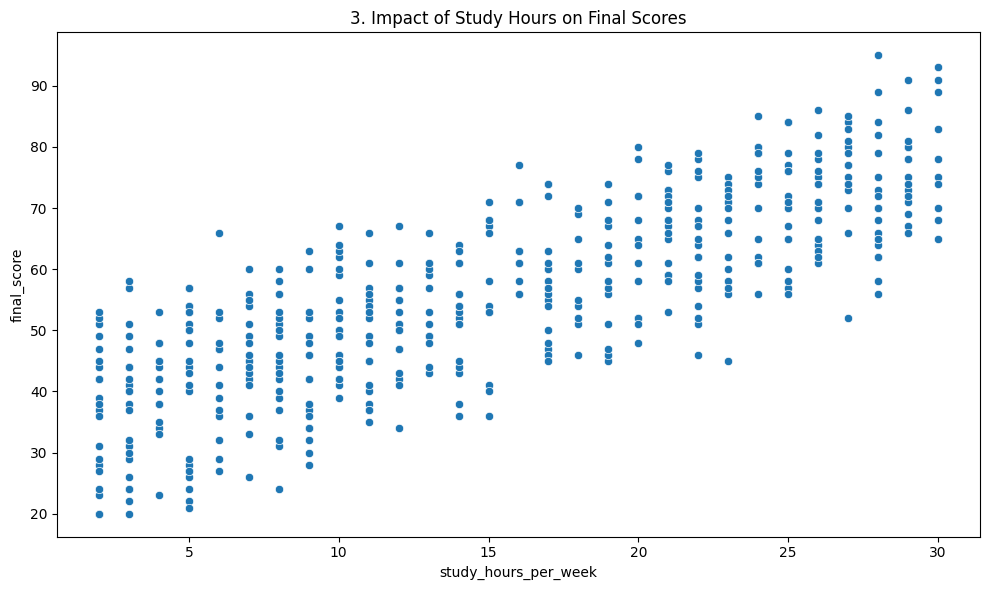

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_week', y='final_score', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on Final Scores')
show_fig()
plot_no += 1

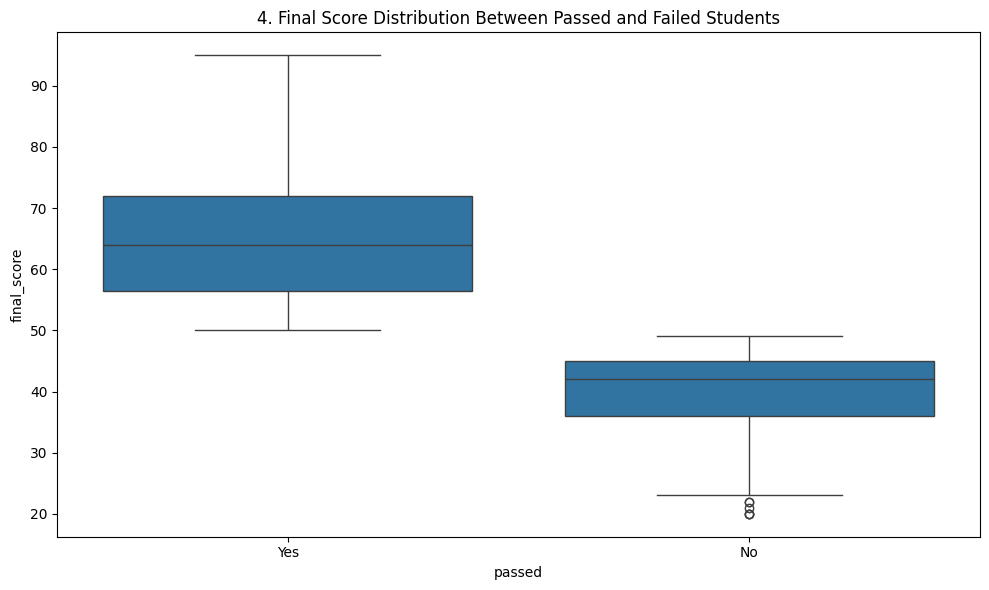

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='passed', y='final_score', data=df)
plt.title(f'{plot_no}. Final Score Distribution Between Passed and Failed Students')
show_fig()
plot_no += 1

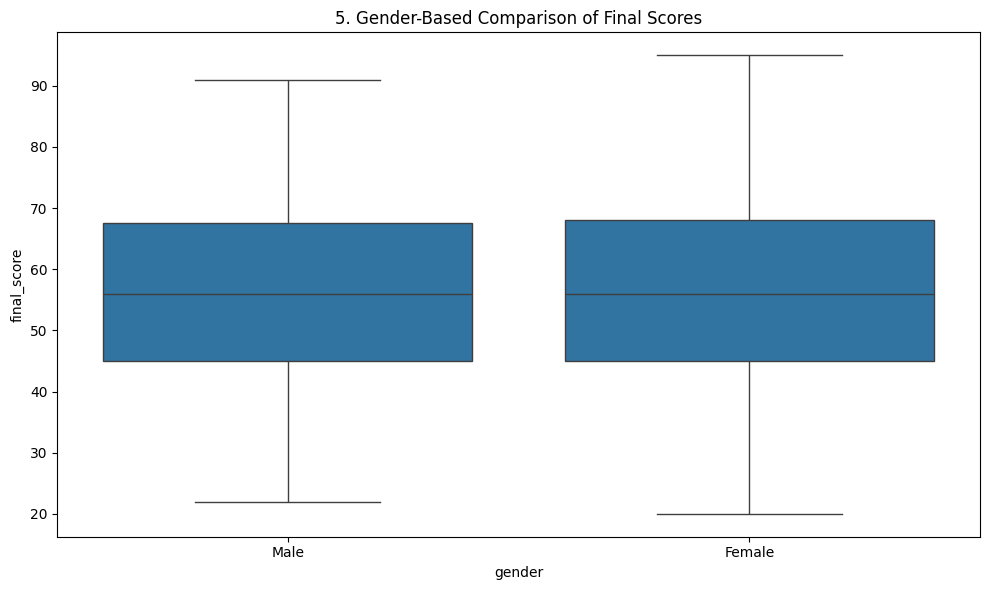

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='final_score', data=df)
plt.title(f'{plot_no}. Gender-Based Comparison of Final Scores')
show_fig()
plot_no += 1

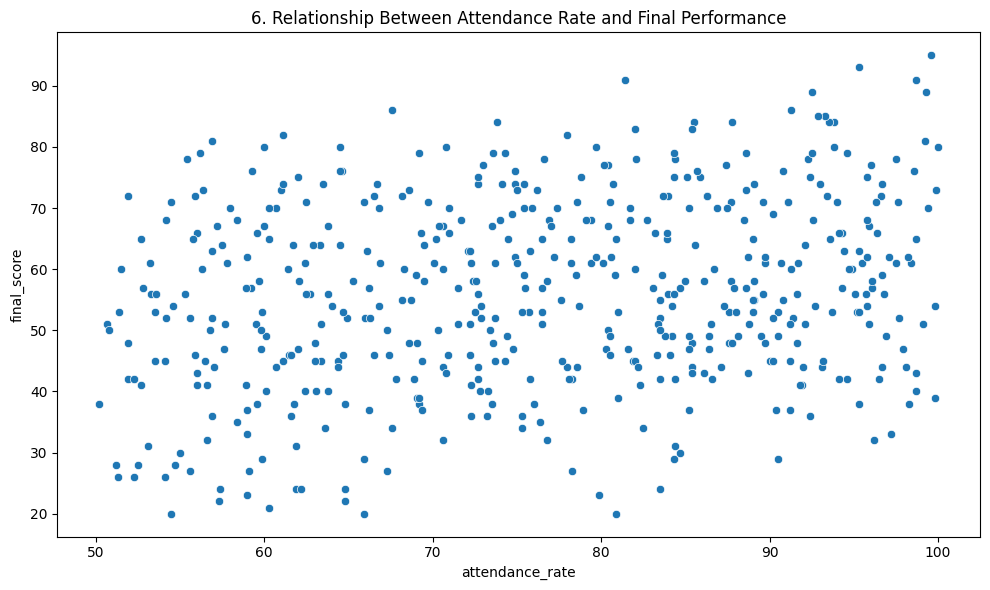

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='attendance_rate', y='final_score', data=df)
plt.title(f'{plot_no}. Relationship Between Attendance Rate and Final Performance')
show_fig()
plot_no += 1

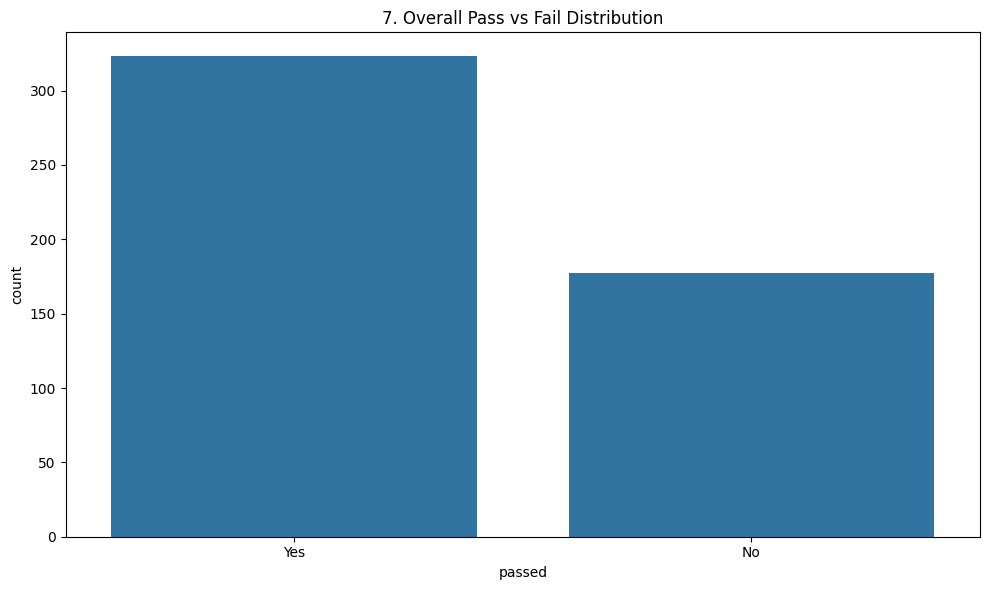

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='passed', data=df)
plt.title(f'{plot_no}. Overall Pass vs Fail Distribution')
show_fig()
plot_no += 1

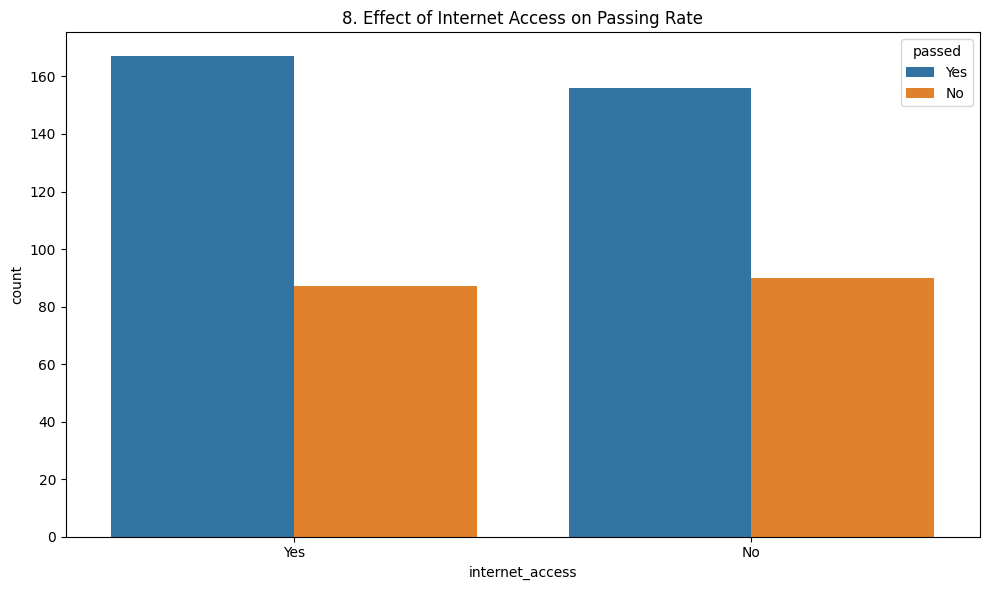

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='internet_access', hue='passed', data=df)
plt.title(f'{plot_no}. Effect of Internet Access on Passing Rate')
show_fig()
plot_no += 1

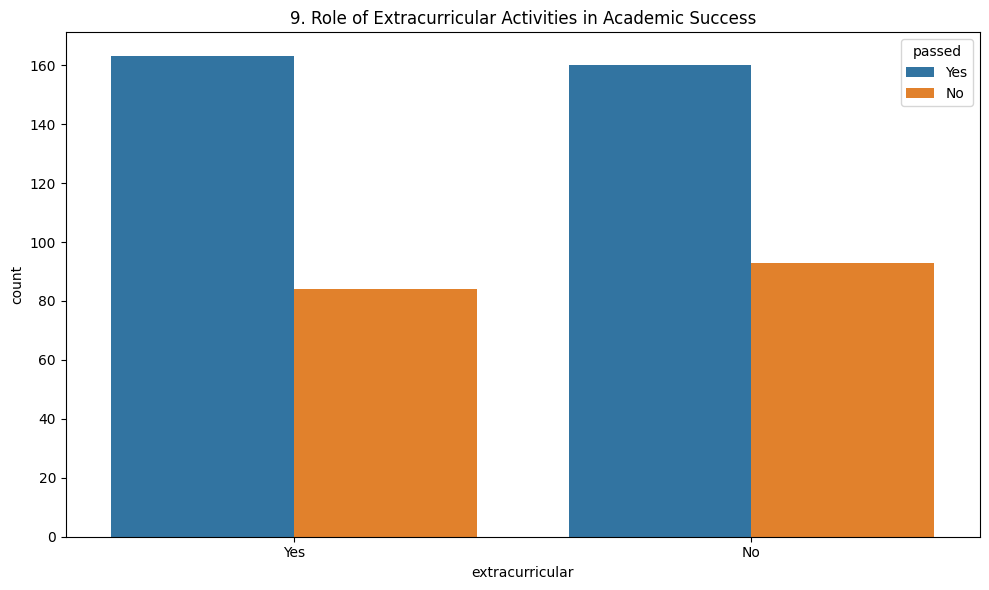

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='extracurricular', hue='passed', data=df)
plt.title(f'{plot_no}. Role of Extracurricular Activities in Academic Success')
show_fig()
plot_no += 1

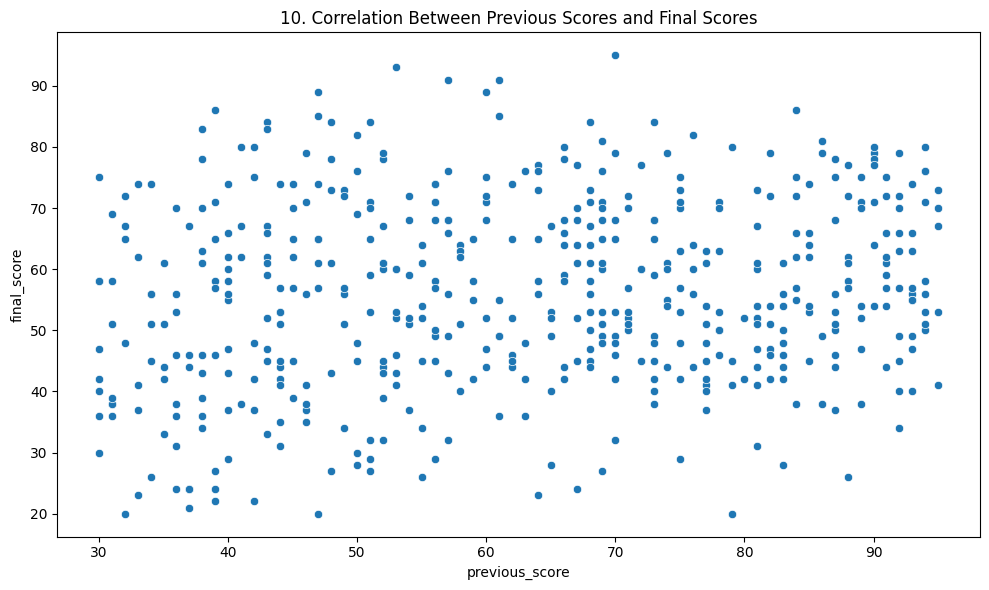

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='previous_score', y='final_score', data=df)
plt.title(f'{plot_no}. Correlation Between Previous Scores and Final Scores')
show_fig()
plot_no += 1

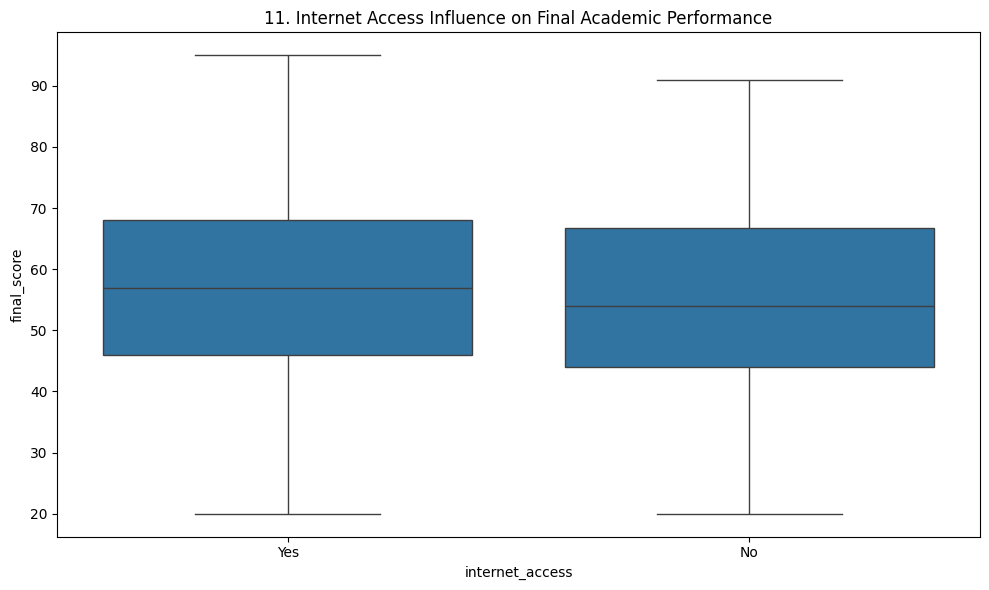

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='internet_access', y='final_score', data=df)
plt.title(f'{plot_no}. Internet Access Influence on Final Academic Performance')
show_fig()
plot_no += 1

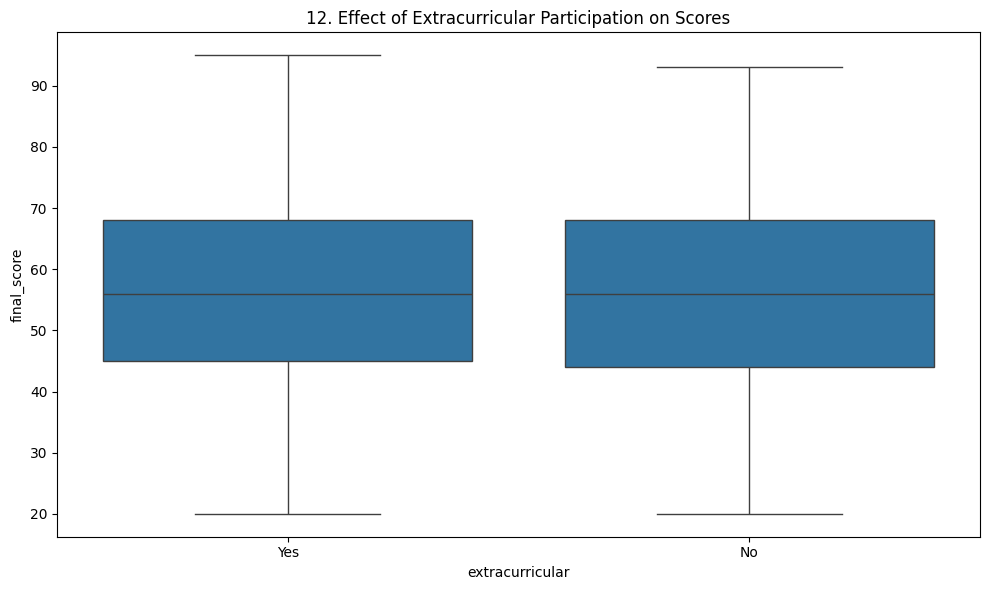

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='extracurricular', y='final_score', data=df)
plt.title(f'{plot_no}. Effect of Extracurricular Participation on Scores')
show_fig()
plot_no += 1

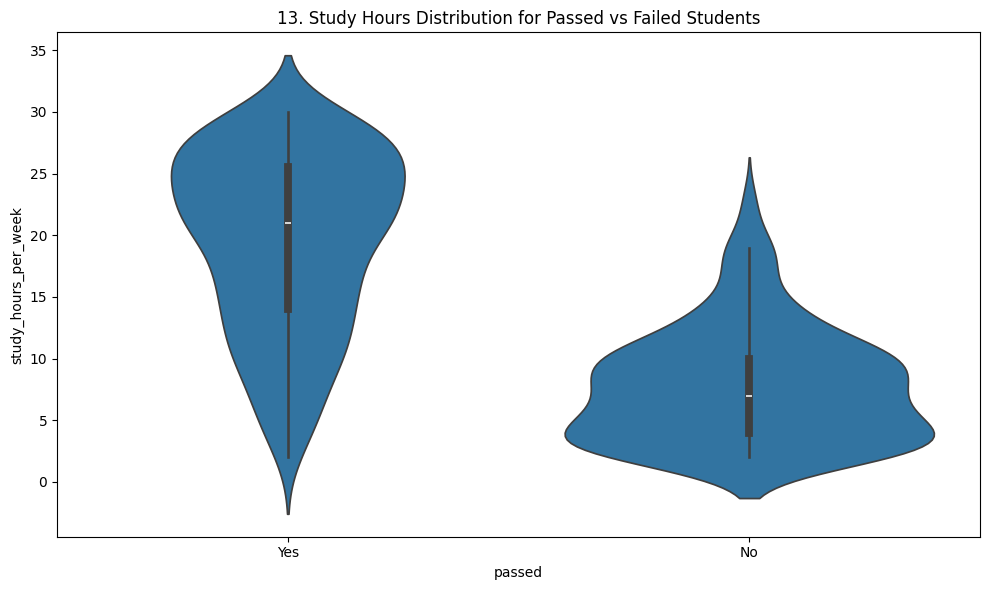

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='passed', y='study_hours_per_week', data=df)
plt.title(f'{plot_no}. Study Hours Distribution for Passed vs Failed Students')
show_fig()
plot_no += 1

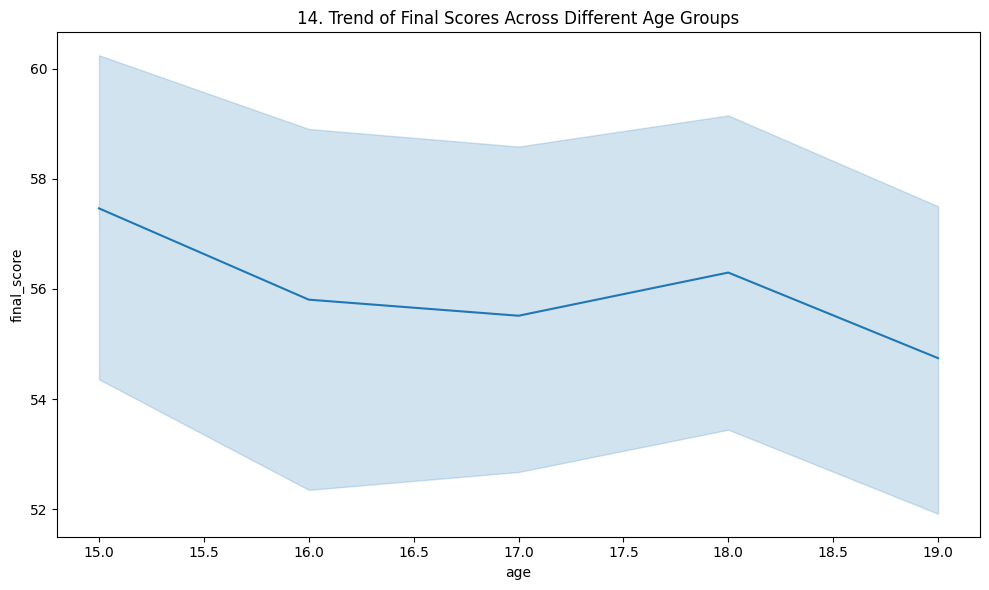

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='age', y='final_score', data=df)
plt.title(f'{plot_no}. Trend of Final Scores Across Different Age Groups')
show_fig()
plot_no += 1

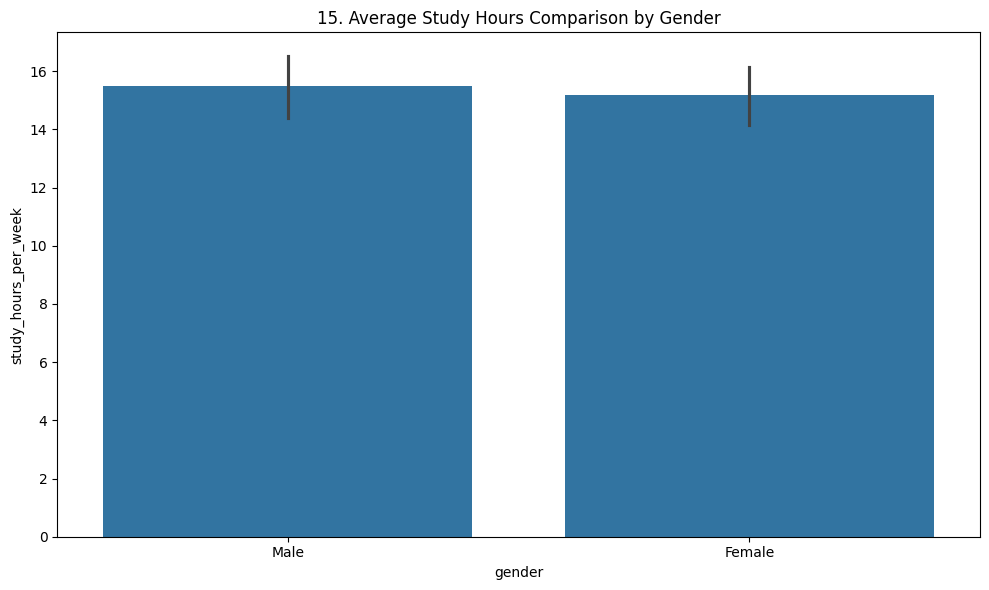

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='gender', y='study_hours_per_week', data=df)
plt.title(f'{plot_no}. Average Study Hours Comparison by Gender')
show_fig()
plot_no += 1

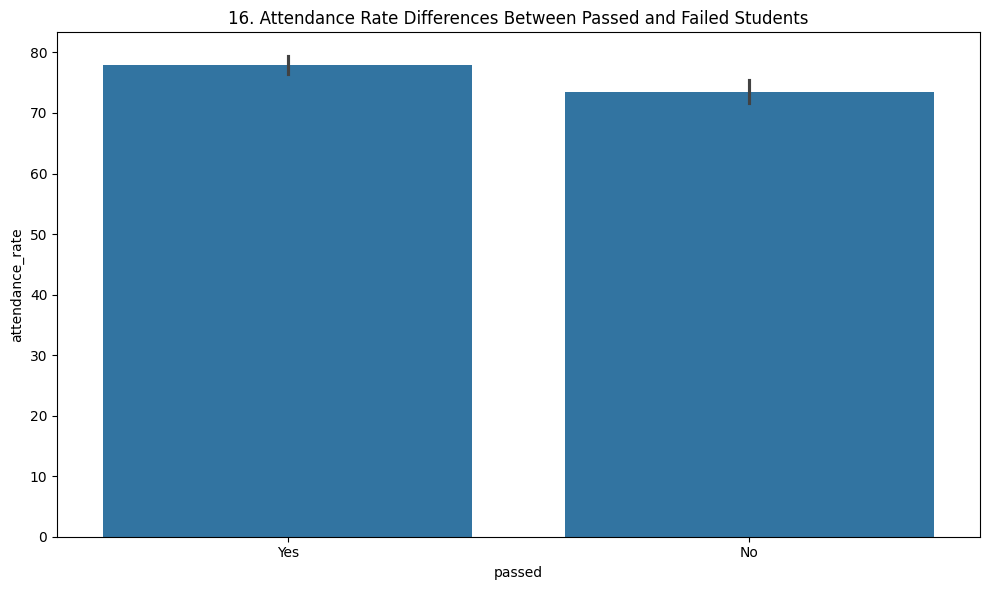

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='passed', y='attendance_rate', data=df)
plt.title(f'{plot_no}. Attendance Rate Differences Between Passed and Failed Students')
show_fig()
plot_no += 1

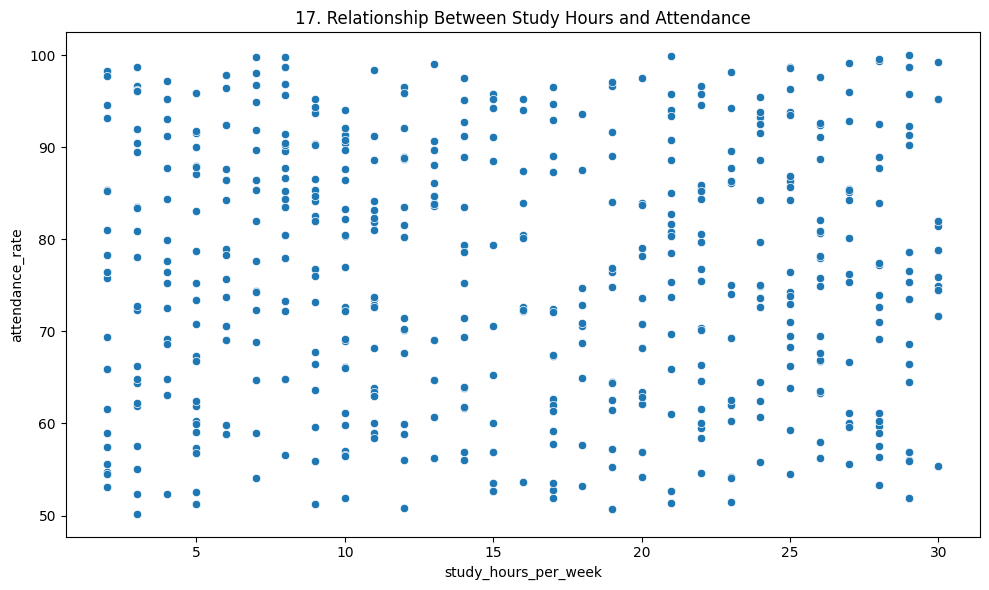

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_week', y='attendance_rate', data=df)
plt.title(f'{plot_no}. Relationship Between Study Hours and Attendance')
show_fig()
plot_no += 1

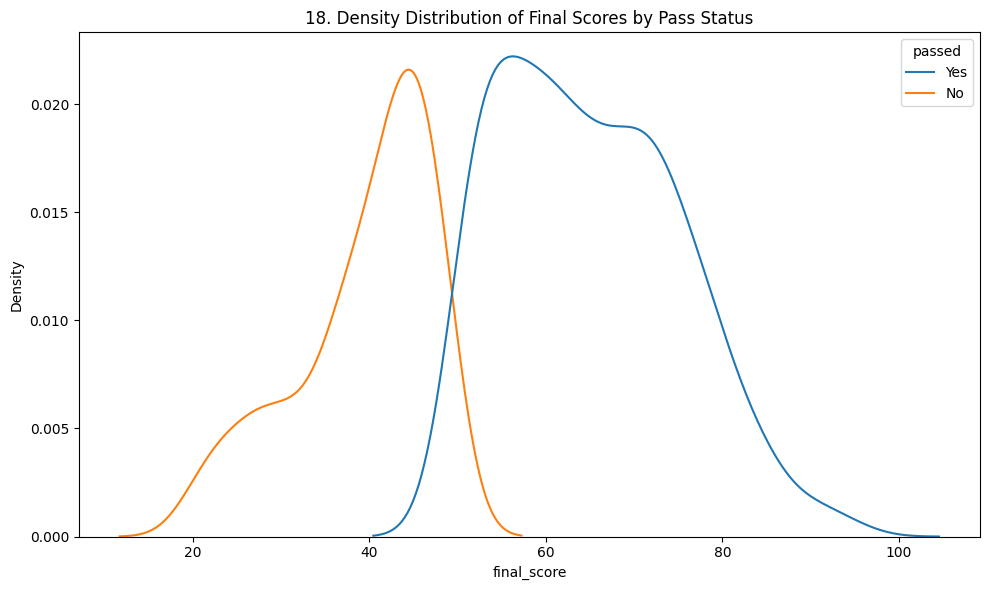

In [31]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(x='final_score', hue='passed', data=df)
plt.title(f'{plot_no}. Density Distribution of Final Scores by Pass Status')
show_fig()
plot_no += 1

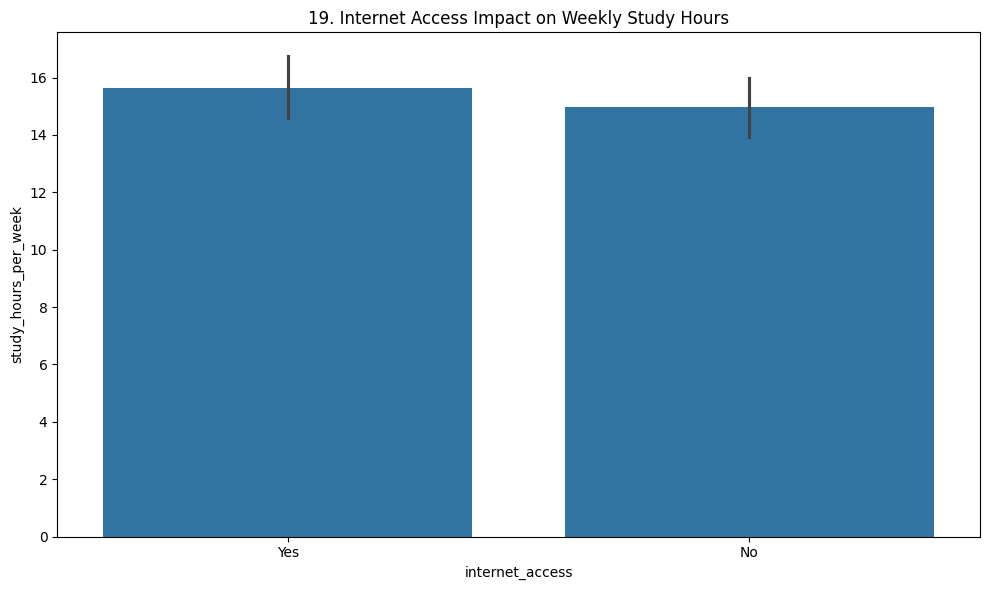

In [32]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='internet_access', y='study_hours_per_week', data=df)
plt.title(f'{plot_no}. Internet Access Impact on Weekly Study Hours')
show_fig()
plot_no += 1

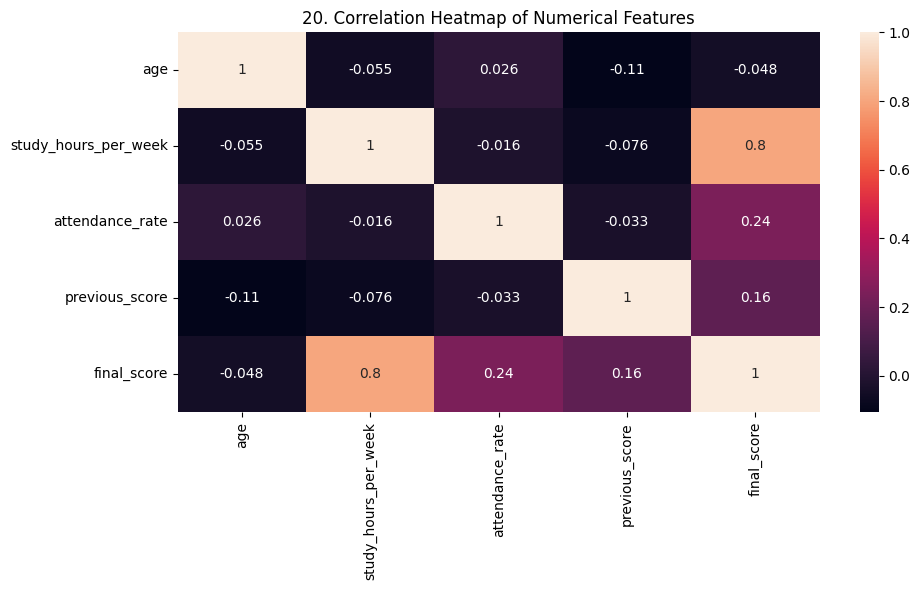

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [34]:
data = df.copy()

## encode categorical variables

In [35]:
le = LabelEncoder()
for col in ['gender', 'internet_access', 'extracurricular', 'passed']:
    data[col] = le.fit_transform(data[col])

## define features and target

In [36]:
X = data.drop(['student_id', 'passed'], axis=1)
y = data['passed']

## split dataset

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply scaling

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model

In [39]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## predictions

In [40]:
y_pred = model.predict(X_test)

## accuracy score

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.97


## confusion matrix

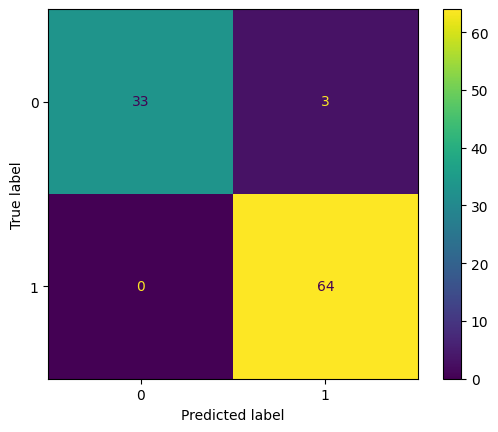

In [42]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()